In [1]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import matplotlib.patches as patches
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
plt.rcParams.update(config)
from matplotlib.ticker import AutoMinorLocator

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g140m-f100lp, g235m-f170lp, prism-clear}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


In [2]:
uv_slope_list=[]
uv_slope_err_list=[]
balmer_ratio_list=[]
balmer_ratio_err_list=[]
redshift_list=[]
plotting_alpha_list=[]

for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    best_SNR=-1
    best_Signal=None
    best_Noise=None
    best_key=None
    for key, dict_value in catalog['lines_fit'].items():

        balmer_decrement_uncertainty=FL.BalmerDecrementUncertainty(dict_value['halpha_flux'],dict_value['halpha_flux_err'],dict_value['hbeta_flux'],dict_value['hbeta_flux_err'])
        balmer_decrement=dict_value['halpha_flux']/dict_value['hbeta_flux']
        snr=abs(balmer_decrement/balmer_decrement_uncertainty)
        if snr>best_SNR:
            best_SNR=snr
            best_Signal=balmer_decrement
            best_Noise=balmer_decrement_uncertainty
            best_key=key

    balmer_ratio_list.append(best_Signal)
    balmer_ratio_err_list.append(best_Noise)
    catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']={key: catalog['lines_fit'][best_key][key] for key in catalog['lines_fit'][best_key].keys()}
    DJAv4Catalog.update_catalog_item(surveyid_subid, catalog)

    uv_slope_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent'])
    uv_slope_err_list.append(catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent_error'])

    if np.log(best_Signal/2.86)<-0.2:
        plotting_alpha_list.append(0.3)
    else:
        plotting_alpha_list.append(1.0)

    redshift_list.append(catalog['determined_redshift'])


uv_slope_array=np.array(uv_slope_list)
uv_slope_err_array=np.array(uv_slope_err_list)
balmer_ratio_array=np.array(balmer_ratio_list)
balmer_ratio_err_array=np.array(balmer_ratio_err_list)
redshift_array=np.array(redshift_list)
balmer_decrement_array=np.log(balmer_ratio_array/(2.86))
balmer_decrement_uncertainty_array=balmer_ratio_err_array/balmer_ratio_array

In [ ]:
def Calzetti_beta(balmer_decrement):
    """
    Calculate the UV slope (beta) using the Calzetti et al. (1994) relation
    based on the Balmer decrement.

    Parameters:
    balmer_decrement (float or np.ndarray): The Balmer decrement (log(Hα/Hβ ratio)).

    Returns:
    float or np.ndarray: The calculated UV slope (beta).
    """
    beta=1.76*balmer_decrement-1.71

    return beta

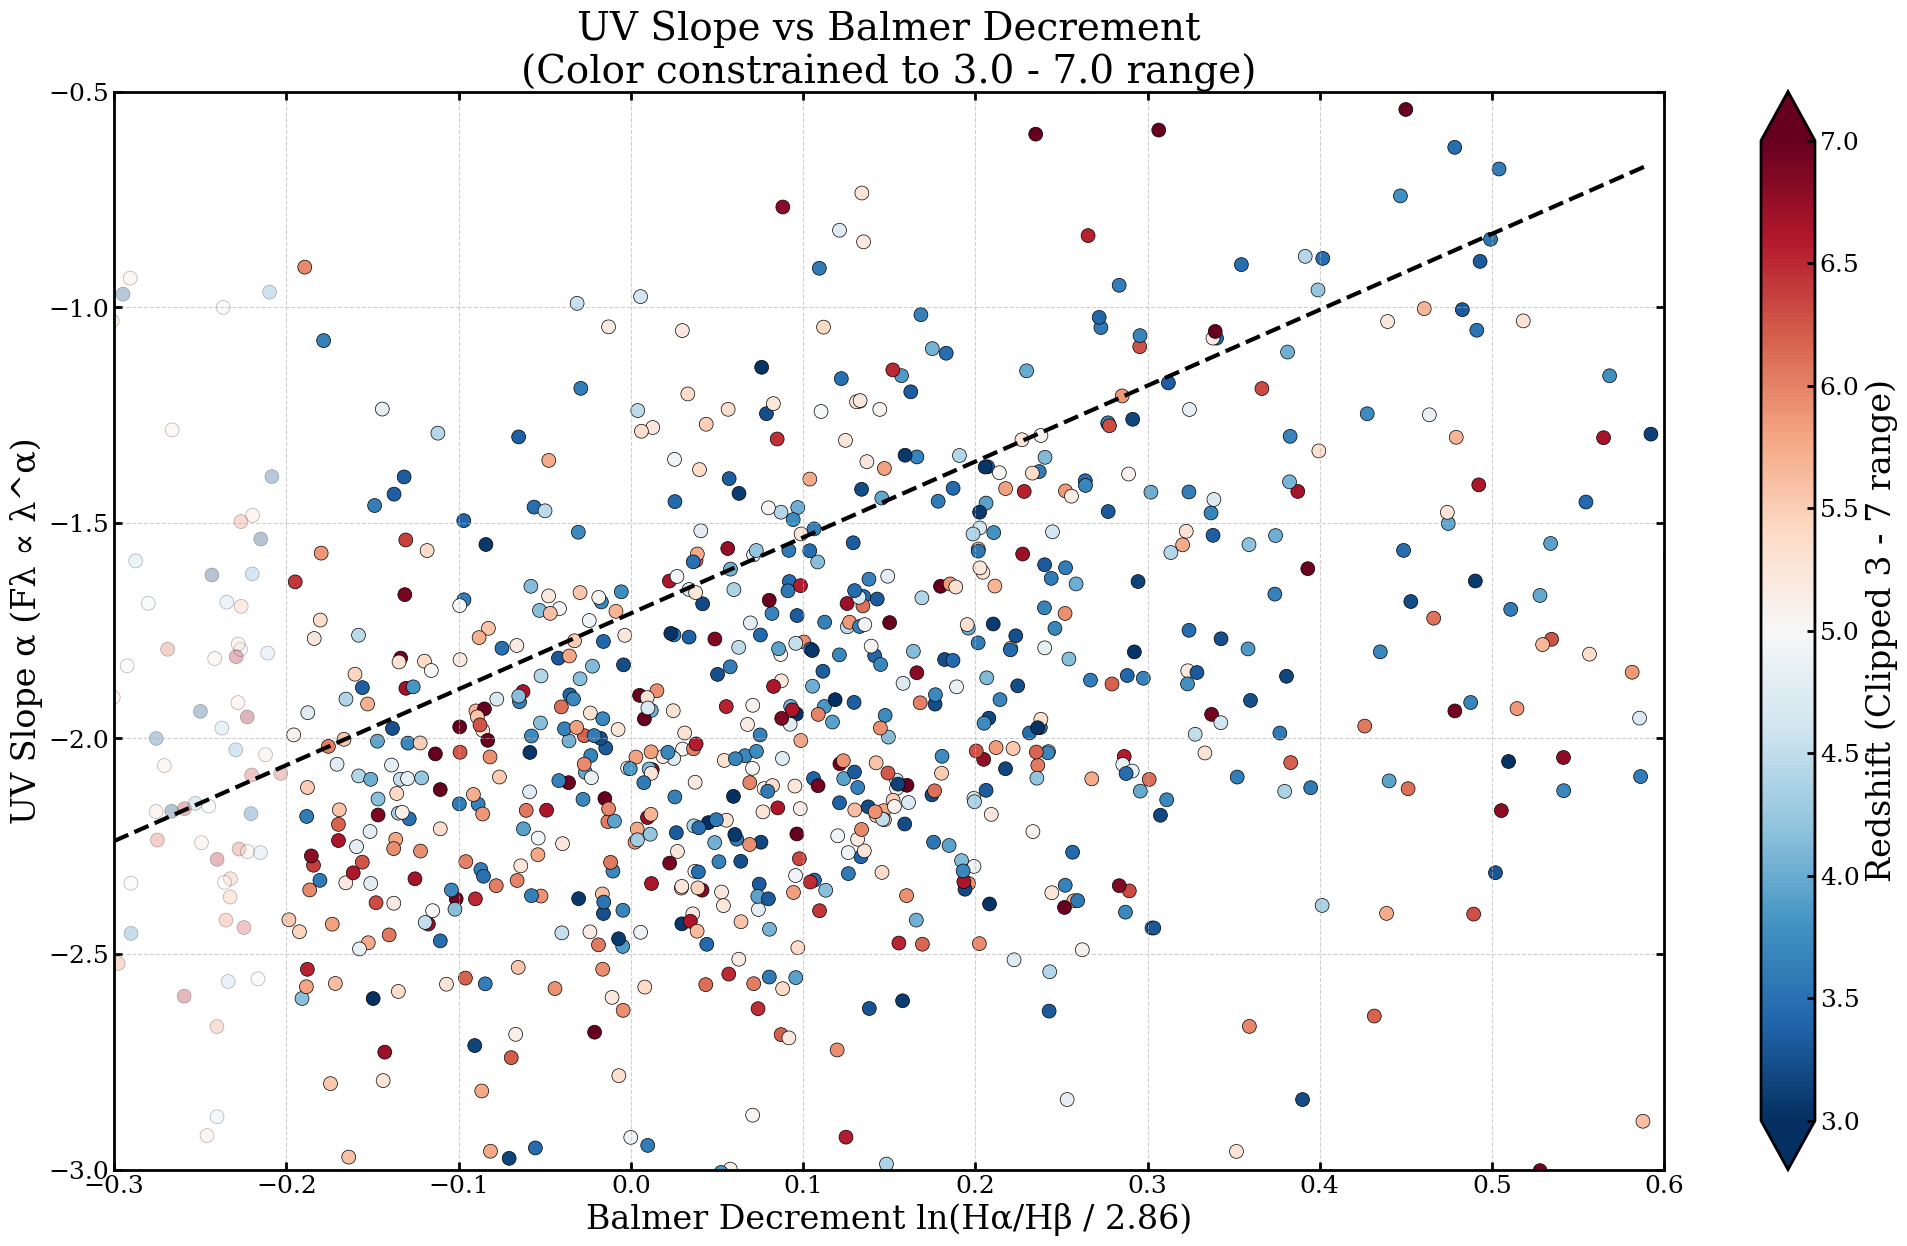

In [7]:
plt.figure(figsize=(25, 14))

# 关键修改：添加 vmin=0.2 和 vmax=1.2
scatter = plt.scatter(balmer_decrement_array,
                        uv_slope_array,
                      c=redshift_array,
                      cmap='RdBu_r',  # 蓝(小) -> 红(大)
                      vmin=3,       # <--- 强制颜色映射下限
                      vmax=7,       # <--- 强制颜色映射上限
                      s=100,
                      alpha=np.array(plotting_alpha_list),
                      edgecolor='k',
                      linewidth=0.5)

# 关键修改：添加 extend='both'
# 这会在颜色条两端显示尖头，表示小于0.2和大于1.2的数据被归类到了边界色
cbar = plt.colorbar(scatter, extend='both')
cbar.set_label('Redshift (Clipped 3 - 7 range)')
plt.plot(np.arange(-0.3,0.6,0.01), Calzetti_beta(np.arange(-0.3,0.6,0.01)), color='black', linestyle='--', label='Calzetti et al. (1994) Relation',linewidth=3)

plt.xlabel('Balmer Decrement ln(Hα/Hβ / 2.86)')
plt.ylabel('UV Slope α (Fλ ∝ λ^α)')
plt.title('UV Slope vs Balmer Decrement\n(Color constrained to 3.0 - 7.0 range)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.3,0.6)
plt.ylim(-3,-0.5)
# plt.savefig('UV_Slope_vs_Balmer_Decrement_Correction_Clipped_0.2_1.2.pdf', bbox_inches='tight', dpi=300)
plt.show()